<a href="https://colab.research.google.com/github/dhfricard-coder/macro-regime-classifier/blob/main/01_setup_and_fred_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install fredapi pandas numpy scikit-learn hmmlearn plotly matplotlib

In [37]:
# I create this field ('FRED_API_KEY') to store key for FRED API
from google.colab import userdata
import os

os.environ['FRED_KEY'] = userdata.get('FRED_KEY')

In [38]:
# I access FRED API
from fredapi import Fred
import pandas as pd
import numpy as np
import os

fred = Fred(api_key=os.getenv("FRED_KEY"))

In [39]:
# Check if i can import unemployment data
series = fred.get_series("UNRATE")
series.tail()

,0
2025-11-01,4.5
2025-12-01,4.4
2026-01-01,4.3
2026-02-01,4.4
2026-03-01,4.3


In [40]:
# PULL AND ENGINEER MACRO FEATURES
# Importing macro data from Federal Reserve Bank of St Louis (a very reliable source for Macro data)

# Fetching each series individually to identify the source of the 'Internal Server Error' if one occurs.
cpi_yoy = fred.get_series('CPIAUCSL').pct_change(12)*100
ism_mfg = fred.get_series('MANEMP')
yield_curve = fred.get_series('T10Y2Y') #high value sindicate steep curve and higher borrowing rates for long term bonds
real_rate = fred.get_series('DFII10') #borrowing rates adjuster per inflation. high values signal higher rates for borrowing. lower values cheap borrowing
credit_spread = fred.get_series('BAMLH0A0HYM2')
unemployment_chg = fred.get_series('UNRATE').diff(3)

data = {
    'cpi_yoy': cpi_yoy,
    'ism_mfg': ism_mfg,
    'yield_curve': yield_curve,
    'real_rate' : real_rate,
    'credit_spread' : credit_spread,
    'unemployment_chg' : unemployment_chg
}

df = pd.DataFrame(data).dropna()
df.head()

/tmp/ipykernel_2426/900132533.py:5: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,cpi_yoy,ism_mfg,yield_curve,real_rate,credit_spread,unemployment_chg
2023-05-01,4.131851,12869.0,-0.55,1.36,4.45,0.0
2023-06-01,3.070617,12875.0,-0.72,1.45,4.65,0.1
2023-08-01,3.722505,12861.0,-0.87,1.68,3.82,0.1
2023-09-01,3.687207,12872.0,-0.69,1.92,3.81,0.1
2023-11-01,3.133346,12859.0,-0.18,2.36,4.47,0.0


In [41]:
df.index = pd.to_datetime(df.index)
df = df.resample('MS').last()   # align to monthly
df = df.dropna()
print(df.tail())
print(df.shape)

             cpi_yoy  ism_mfg  yield_curve  real_rate  credit_spread  \
2025-04-01  2.325388  12662.0         0.30       1.84           3.50   
2025-05-01  2.377265  12651.0         0.55       2.00           3.78   
2025-07-01  2.742618  12625.0         0.48       1.97           2.91   
2025-08-01  2.938592  12615.0         0.54       1.90           3.13   
2025-12-01  2.653304  12580.0         0.55       1.85           2.94   

            unemployment_chg  
2025-04-01               0.2  
2025-05-01               0.1  
2025-07-01               0.1  
2025-08-01               0.0  
2025-12-01               0.0  
(19, 6)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

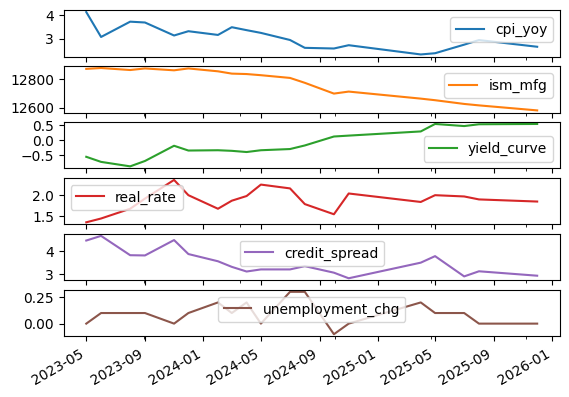

In [42]:
df.plot(subplots=True)

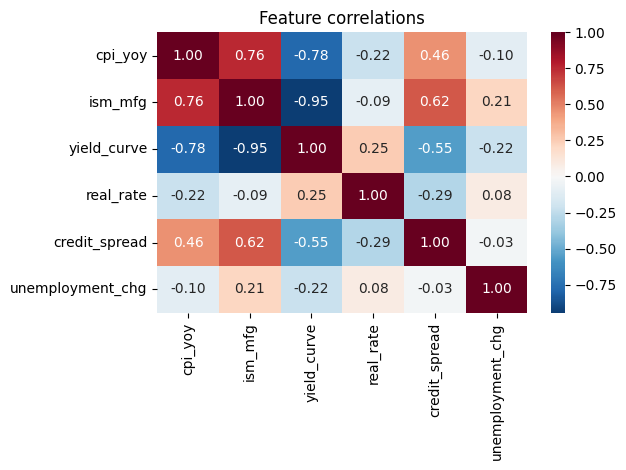

In [43]:
# Check Correlations
# Visualize pairwise correlations between features using a heatmap.
# - seaborn: provides a high-level, aesthetically pleasing heatmap
# - df.corr(): computes correlation matrix (linear relationships)
# - annot=True: display correlation values inside each cell
# - fmt='.2f': format values to 2 decimal places
# - cmap='RdBu_r': diverging color map (red = positive, blue = negative)
# - center=0: ensures colors are centered around zero correlation
# - matplotlib: used to add title and adjust layout for readability

import seaborn as sns #more automatic than matplot lib
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature correlations')
plt.tight_layout()

In [44]:
# BUILD THE REGIME CLASSIFIER
# Standardize features to have mean = 0 and standard deviation = 1.
# - StandardScaler learns the mean and std of each column (fit)
# - Then transforms the data using (x - mean) / std (transform)
# - This ensures all features are on the same scale, which is important for many ML models
# - Output is a NumPy array (not a DataFrame)from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X = scaler.fit_transform(df)

In [45]:
#Fit the GMM and assign regimes
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42,
    n_init=10        # run 10 initialisations, pick the best
)
gmm.fit(X)

df['regime'] = gmm.predict(X)
df['regime_prob'] = gmm.predict_proba(X).max(axis=1)  # save the confidence score

In [46]:
regime_means = df.groupby('regime')[df.columns[:-2]].mean()
regime_means

,cpi_yoy,ism_mfg,yield_curve,real_rate,credit_spread,unemployment_chg
regime,,,,,,
0,2.619355,12648.714286,0.387143,1.878571,3.165714,0.042857
1,3.373515,12852.800000,-0.378000,2.080000,3.736000,0.060000
2,3.641658,12868.333333,-0.713333,1.496667,4.306667,0.066667
3,3.016622,12815.750000,-0.295000,1.902500,3.310000,0.250000


In [47]:
# Interpret each regime
df.index = pd.to_datetime(df.index)
df = df.resample('MS').last()   # align to monthly
df = df.dropna()
print(df.tail())
print(df.shape)

             cpi_yoy  ism_mfg  yield_curve  real_rate  credit_spread  \
2025-04-01  2.325388  12662.0         0.30       1.84           3.50   
2025-05-01  2.377265  12651.0         0.55       2.00           3.78   
2025-07-01  2.742618  12625.0         0.48       1.97           2.91   
2025-08-01  2.938592  12615.0         0.54       1.90           3.13   
2025-12-01  2.653304  12580.0         0.55       1.85           2.94   

            unemployment_chg  regime  regime_prob  
2025-04-01               0.2     0.0          1.0  
2025-05-01               0.1     0.0          1.0  
2025-07-01               0.1     0.0          1.0  
2025-08-01               0.0     0.0          1.0  
2025-12-01               0.0     0.0          1.0  
(19, 8)


In [48]:
#Map regimes
df.index = pd.to_datetime(df.index)
df = df.resample('MS').last()   # align to monthly
df = df.dropna()
print(df.tail())
print(df.shape)

             cpi_yoy  ism_mfg  yield_curve  real_rate  credit_spread  \
2025-04-01  2.325388  12662.0         0.30       1.84           3.50   
2025-05-01  2.377265  12651.0         0.55       2.00           3.78   
2025-07-01  2.742618  12625.0         0.48       1.97           2.91   
2025-08-01  2.938592  12615.0         0.54       1.90           3.13   
2025-12-01  2.653304  12580.0         0.55       1.85           2.94   

            unemployment_chg  regime  regime_prob  
2025-04-01               0.2     0.0          1.0  
2025-05-01               0.1     0.0          1.0  
2025-07-01               0.1     0.0          1.0  
2025-08-01               0.0     0.0          1.0  
2025-12-01               0.0     0.0          1.0  
(19, 8)


In [49]:
# Regime interpretation (based on macro feature averages):
# - Regime 1: Expansion / Risk-on → strong growth, improving labor market, low financial stress
# - Regime 0: Recovery / Early cycle → steep yield curve, low inflation, residual credit stress
# - Regime 3: Late cycle / Tightening → strong growth with high real rates, policy tightening, turning point
# - Regime 2: Recession / Risk-off → weak growth, rising unemployment, wide credit spreads, financial stress

# Cycle progression: Recovery → Expansion → Late Cycle → Recession

In [50]:
regime_map = {0: 'Recovery', 1: 'Expansion', 2: 'Recession', 3: 'Late Cycle'}
# adjust numbers based on what your clusters actually show
df['regime_label'] = df['regime'].map(regime_map)

In [51]:
#Regimes over time
import plotly.express as px
fig = px.scatter(df.reset_index(), x='index', y='cpi_yoy',
                 color='regime_label', title='Macro regimes over time (CPI YoY)')
fig.show()

In [52]:
# MAP REGIMES TO ASSET RETURNS
#Pull asset return data: You download monthly prices for key asset classes, convert them into returns, and align dates to month-start timestamps

import yfinance as yf

tickers = ['SPY', 'TLT', 'GLD', 'DBC'] #SPY=equities, TLT=long-duration bonds, GLD=gold, DBC=broad commodities
prices = yf.download(tickers, start='1997-01-01', end='2024-12-31', interval='1mo')['Close'] #1mo is montly data. Adj CLose represents true investor return (includes dividends & splits)
returns = prices.pct_change().dropna() #computes monthly returns
returns.index = returns.index.to_period('M').to_timestamp() #to align with our macro data at beginning of month
returns.head()


/tmp/ipykernel_2426/1073087507.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  4 of 4 completed


Ticker,DBC,GLD,SPY,TLT
Date,,,,
2006-03-01,0.027909,0.036205,0.012478,-0.045664
2006-04-01,0.070175,0.120310,0.016659,-0.027790
2006-05-01,-0.003903,-0.013212,-0.030121,-0.002054
2006-06-01,-0.008621,-0.046707,-0.001803,0.011736
2006-07-01,0.022134,0.031521,0.008918,0.021724


In [53]:
#Merge with regime labels
regime_monthly = df[['regime_label']].copy()
regime_monthly.index = regime_monthly.index.to_period('M').to_timestamp()
merged = returns.join(regime_monthly, how='inner').dropna()

In [54]:
results

{'SPY':               Mean Return    Sharpe  Hit Rate  Max Drawdown
 regime_label                                               
 Expansion        0.388985  2.159608  0.800000      0.000000
 Late Cycle       0.160766  1.243009  0.750000     -0.037338
 Recession        0.196893  1.425052  0.666667     -0.016252
 Recovery         0.322499  2.009534  0.500000      0.000000,
 'TLT':               Mean Return    Sharpe  Hit Rate  Max Drawdown
 regime_label                                               
 Expansion        0.334661  1.361429  0.800000      0.000000
 Late Cycle      -0.098599 -0.618656  0.500000     -0.064710
 Recession       -0.238288 -3.625583  0.333333     -0.031467
 Recovery        -0.208808 -1.148039  0.500000      0.000000,
 'GLD':               Mean Return     Sharpe  Hit Rate  Max Drawdown
 regime_label                                                
 Expansion        0.224164   1.356492       0.8      0.000000
 Late Cycle       0.327159   4.608644       1.0      0.0000

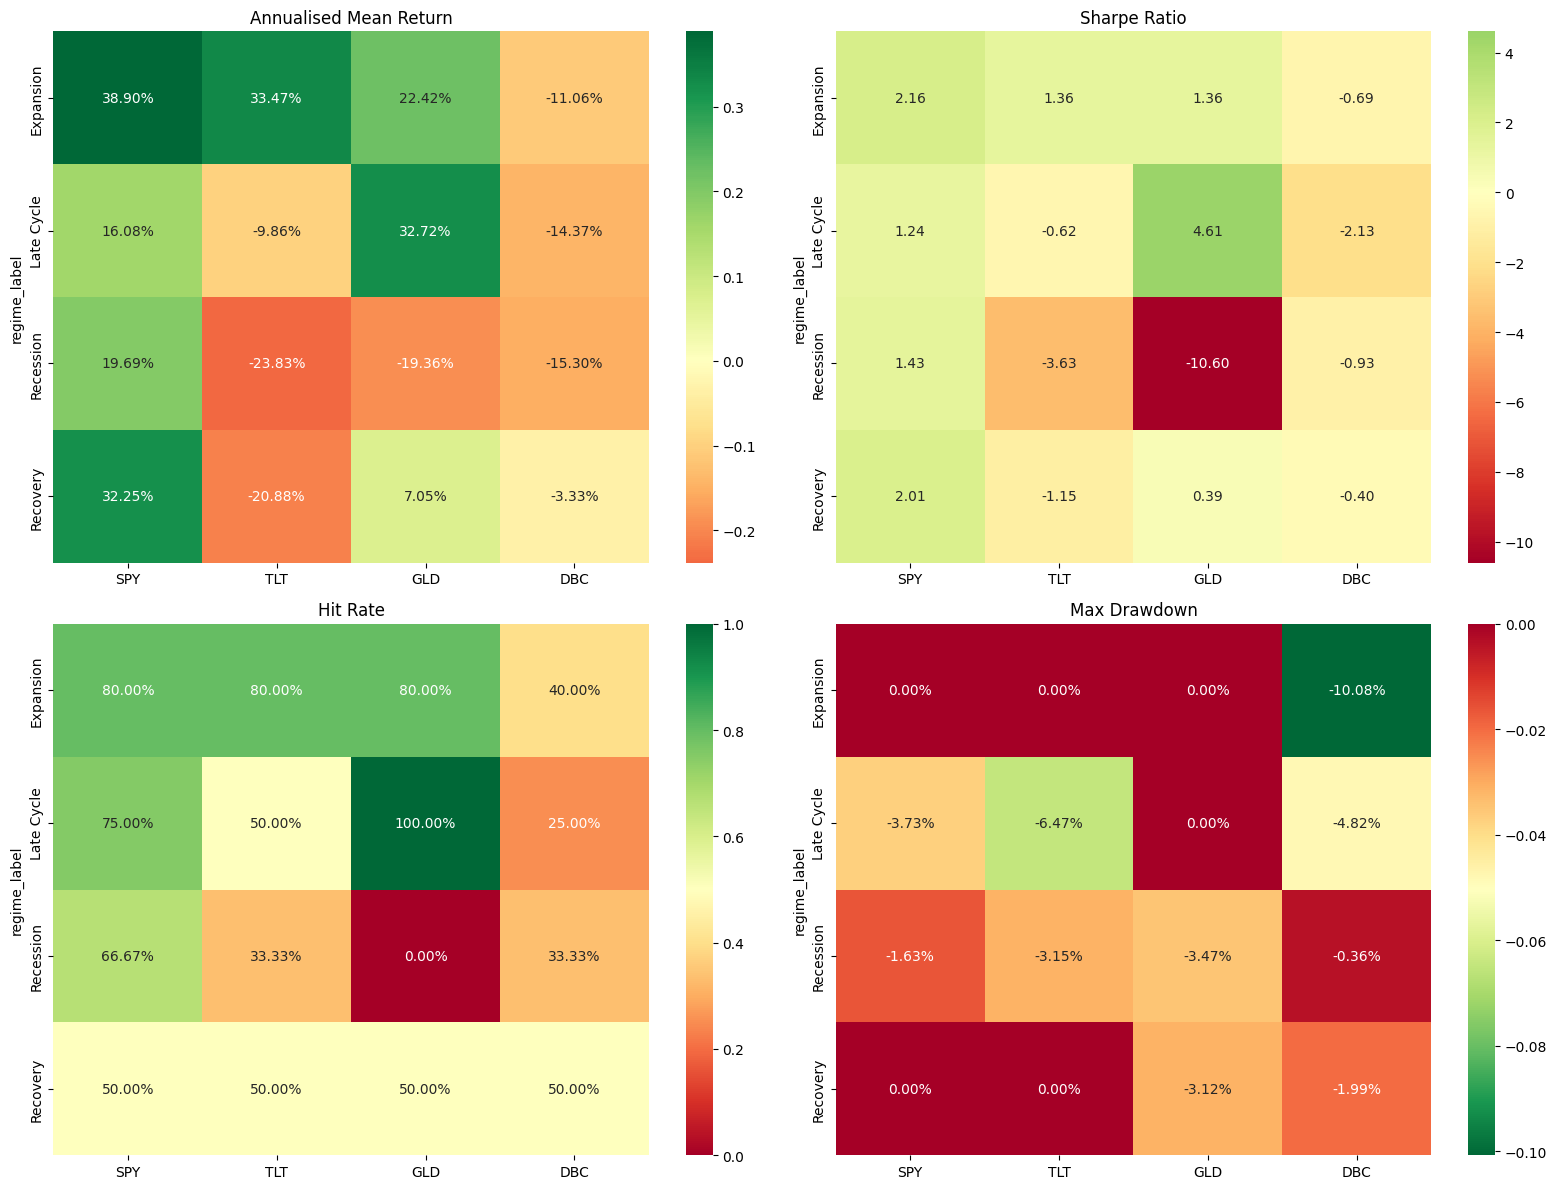

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Compute statistics per regime per asset
#You compute performance metrics (returns, risk, drawdowns) for each asset within each regime, then visualize results
# =========================
# Metrics
# =========================
def sharpe(x):
    return x.mean() / x.std() * np.sqrt(12)

def hit_rate(x):
    return (x > 0).mean()  # % of periods with positive returns

def max_dd(x):  # Measures largest loss from peak to trough
    cum = (1 + x).cumprod()
    return (cum / cum.cummax() - 1).min()

# =========================
# Compute metrics by regime
# =========================
results = {}

for asset in tickers:
    results[asset] = merged.groupby('regime_label')[asset].agg([
        ('Mean Return', lambda x: x.mean() * 12),
        ('Sharpe', sharpe),
        ('Hit Rate', hit_rate),
        ('Max Drawdown', max_dd)
    ])

# =========================
# Helper to extract metric
# =========================
def build_metric_df(results, tickers, metric):
    return pd.DataFrame({a: results[a][metric] for a in tickers})

# Build all matrices
mean_df   = build_metric_df(results, tickers, 'Mean Return')
sharpe_df = build_metric_df(results, tickers, 'Sharpe')
hit_df    = build_metric_df(results, tickers, 'Hit Rate')
dd_df     = build_metric_df(results, tickers, 'Max Drawdown')

# =========================
# Plot all heatmaps together
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mean Return
sns.heatmap(mean_df, annot=True, fmt='.2%', cmap='RdYlGn', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Annualised Mean Return')

# Sharpe
sns.heatmap(sharpe_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0, 1])
axes[0, 1].set_title('Sharpe Ratio')

# Hit Rate
sns.heatmap(hit_df, annot=True, fmt='.2%', cmap='RdYlGn', center=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Hit Rate')

# Max Drawdown (reversed colors: worse = red)
sns.heatmap(dd_df, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=axes[1, 1])
axes[1, 1].set_title('Max Drawdown')

plt.tight_layout()
plt.show()

In [56]:
#Step V: Build the risk framework
#Regime transition matrix

regimes = df['regime_label'].values #Convert it into a NumPy array
transitions = pd.crosstab( #Counts how often each (From → To) pair occurs
    pd.Series(regimes[:-1], name='From'),
    pd.Series(regimes[1:], name='To'),
    normalize='index'
)
print(transitions.round(2))
# This shows: given we're in Recession, how likely is each regime next month?

To          Expansion  Late Cycle  Recession  Recovery
From                                                  
Expansion        0.40        0.60       0.00      0.00
Late Cycle       0.50        0.25       0.00      0.25
Recession        0.33        0.00       0.67      0.00
Recovery         0.00        0.00       0.00      1.00


In [57]:
# Confidence scoring and position sizing rule
df['uncertain'] = df['regime_prob'] < 0.6

# What today's environment looks like
today_features = X[-1].reshape(1, -1)
today_probs = gmm.predict_proba(today_features)[0]
today_regime = gmm.predict(today_features)[0]
today_confidence = today_probs.max()

print(f"Current regime: {regime_map[today_regime]}")
print(f"Confidence: {today_confidence:.1%}")
print(f"Position sizing: {'50% (uncertain)' if today_confidence < 0.6 else 'Full'}")

Current regime: Recovery
Confidence: 100.0%
Position sizing: Full


In [58]:
df.head()

,cpi_yoy,ism_mfg,yield_curve,real_rate,credit_spread,unemployment_chg,regime,regime_prob,regime_label,uncertain
2023-05-01,4.131851,12869.0,-0.55,1.36,4.45,0.0,2.0,1.0,Recession,False
2023-06-01,3.070617,12875.0,-0.72,1.45,4.65,0.1,2.0,1.0,Recession,False
2023-08-01,3.722505,12861.0,-0.87,1.68,3.82,0.1,2.0,1.0,Recession,False
2023-09-01,3.687207,12872.0,-0.69,1.92,3.81,0.1,1.0,1.0,Expansion,False
2023-11-01,3.133346,12859.0,-0.18,2.36,4.47,0.0,1.0,1.0,Expansion,False


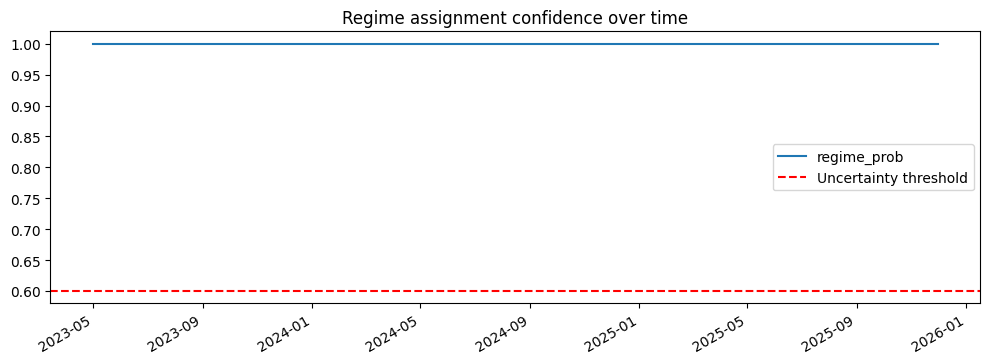

In [59]:
#Visualize confidence over time
df['regime_prob'].plot(title='Regime assignment confidence over time', figsize=(12,4))
plt.axhline(0.6, color='red', linestyle='--', label='Uncertainty threshold')
plt.legend()